# k ablation — GREAC × KEVOLVE × CASTOR-KRFE

Brings together the three k sweeps of **one organism** to answer the reviews. Each run produces one chart per
section, for that organism only, in `figs/comparison/<organism>/`.

| review | where |
|---|---|
| 1. compare the three methods at the best F1 each one reaches, not at one fixed k | sections 1 and 3 |
| 2. full F1 × k curve for GREAC | section 1 |
| 3. CASTOR-KRFE through its native `k_min..k_max` search | sections 1 and 3 (points at the chosen k) |
| 4. KEVOLVE with its own k sweep | sections 1 and 3 |
| 5. runtime alongside F1 | sections 2 and 3 |

**Where each curve comes from** (macro F1 throughout):

- **GREAC** — `GREAC/output-sweep-<org>/parameter_sweep_<org>*.csv`. For each k, the best window × threshold
  combination (highest mean F1 among those with coverage ≥ `MIN_COVERAGE`), with mean ± SD over the
  repetitions. Time = extraction + fit + classification of that combination; the cache is cleared for every
  combination, so it is the whole pipeline.
- **KEVOLVE** — `kevolve-kmer-sweep/reports.csv`. k is a fixed input: one curve, mean ± SD per k.
  Time = the whole run (`seconds`).
- **CASTOR-KRFE** — `castor-kmer-sweep/`. The method searches k by itself within `k_min..k_max` (1–10 in the
  sweep), so k is an *outcome*: each run becomes a point at the k it chose, with no line. Time = `duration_s`
  from `summary.csv`, which includes the whole k search.

**Parameters** (next cell):

- `ORGANISM` — `denv`, `hbv`, `hiv`, `sars` or `mkpx`
- `MIN_COVERAGE` — same rule as `greac_sweep.ipynb`: a GREAC combination that classifies less than this
  fraction of the test set is left out
- `DECIMALS` — decimal places in the tables

It also runs without opening Jupyter, one organism at a time:

```bash
for o in denv hbv hiv sars mkpx; do
  papermill kmer_methods_comparison.ipynb /dev/null -p ORGANISM $o
done
```

In [1]:
ORGANISM = "denv"     # denv, hbv, hiv, sars, mkpx
MIN_COVERAGE = 0.95
DECIMALS = 3

In [2]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GREAC_ROOT = os.path.join("..", "GREAC")
GREAC_ALIAS = {"mkpx": "monkeypox"}    # the GREAC mkpx sweep was written as monkeypox
KEVOLVE_DIR, CASTOR_DIR = "kevolve-kmer-sweep", "castor-kmer-sweep"
FIG_DIR = os.path.join("figs", "comparison", ORGANISM)
os.makedirs(FIG_DIR, exist_ok=True)

METHODS = ["GREAC", "KEVOLVE", "CASTOR-KRFE"]
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # same fixed order as the other notebooks
COLOR = dict(zip(METHODS, SERIES))
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#a3a29d", "#e3e2dd", "#fcfcfb"
K_AXIS = list(range(1, 11))
TITLE = ORGANISM.upper()

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlelocation": "center",
    "axes.titlepad": 8, "axes.labelsize": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6, "font.size": 10, "figure.dpi": 120,
})


def rounded(df):
    return df.round(DECIMALS)


def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), bbox_inches="tight")

## Loading the data

One long table per method: one row per (organism, k, repetition) with macro F1 and seconds.

In [3]:
def load_greac(org):
    d = os.path.join(GREAC_ROOT, f"output-sweep-{org}")
    name = org
    if not glob.glob(os.path.join(d, "parameter_sweep_*.csv")) and org in GREAC_ALIAS:
        name = GREAC_ALIAS[org]
        d = os.path.join(GREAC_ROOT, f"output-sweep-{name}")
    # same shards as greac_sweep.ipynb; the timestamped archived ones are left out
    paths = [p for p in [os.path.join(d, f"parameter_sweep_{name}.csv")]
             + sorted(glob.glob(os.path.join(d, f"parameter_sweep_{name}.part-*.csv")))
             if os.path.exists(p)]
    if not paths:
        return pd.DataFrame(), np.nan
    raw = pd.concat(map(pd.read_csv, paths), ignore_index=True)
    raw = raw.drop_duplicates(subset=["rep", "window", "threshold", "kmer"], keep="last")
    raw["window"] = raw["window"].round(6)
    raw["threshold"] = raw["threshold"].round(3)
    raw["coverage"] = raw["n_test"] / raw.groupby("rep")["n_test"].transform("max")
    raw["seconds"] = raw["extract_time"] + raw["fit_time"] + raw["classify_time"]

    # best window × threshold per k (mean F1), only among those with enough coverage
    keys = ["window", "threshold", "kmer"]
    combo = raw.groupby(keys).agg(f1=("f1_score", "mean"), cov=("coverage", "mean"),
                                  seconds=("seconds", "mean")).reset_index()
    best = (combo[combo["cov"] >= MIN_COVERAGE].sort_values("f1", ascending=False)
            .drop_duplicates("kmer")[keys])
    runs = raw.merge(best, on=keys)
    # combo.seconds.sum() = cost of sweeping the whole grid once (section 3)
    return pd.DataFrame({"organism": org, "method": "GREAC", "k": runs.kmer, "repeat": runs.rep,
                         "f1": runs.f1_score, "seconds": runs.seconds,
                         "config": "w=" + runs.window.astype(str) + " t=" + runs.threshold.astype(str)}), \
        combo.seconds.sum()


def load_kevolve():
    r = pd.read_csv(os.path.join(KEVOLVE_DIR, "reports.csv"))
    r = r[r.label == "macro avg"].drop_duplicates(subset=["organism", "k", "repeat"], keep="last")
    return pd.DataFrame({"organism": r.organism, "method": "KEVOLVE", "k": r.k.astype(int),
                         "repeat": r.repeat, "f1": r.f1_score, "seconds": r.seconds})


def load_castor():
    r = pd.read_csv(os.path.join(CASTOR_DIR, "reports.csv"))
    r = r[r.label == "macro avg"].drop_duplicates(subset=["organism", "repeat"], keep="last")
    s = pd.read_csv(os.path.join(CASTOR_DIR, "summary.csv"))
    # some reruns are marked "success" with no F1 and ~1 s (the method did not run): without
    # the f1_score filter they replace the real run in drop_duplicates
    s = s[(s.status == "success") & s.f1_score.notna()]
    s = s.drop_duplicates(subset=["organism", "repeat"], keep="last")
    r = r.merge(s[["organism", "repeat", "duration_s"]], on=["organism", "repeat"], how="left")
    return pd.DataFrame({"organism": r.organism, "method": "CASTOR-KRFE", "k": r.k_length.astype(int),
                         "repeat": r.repeat, "f1": r.f1_score, "seconds": r.duration_s})


greac_runs, GREAC_GRID_S = load_greac(ORGANISM)
runs = pd.concat([greac_runs, load_kevolve(), load_castor()], ignore_index=True)
runs = runs[runs.organism == ORGANISM]
if runs.empty:
    raise ValueError(f"ORGANISM {ORGANISM!r} has no data in any of the three sweeps")

per_k = (runs.groupby(["method", "k"])
         .agg(n=("repeat", "nunique"), f1_mean=("f1", "mean"), f1_std=("f1", "std"),
              seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"))
         .reset_index())

# k covered by each method: shows what is still missing to have 1–10 for all
per_k.groupby("method").k.agg(lambda ks: f"{min(ks)}–{max(ks)} ({len(ks)} values)").rename("k").to_frame()

,k
method,
CASTOR-KRFE,3–10 (8 valores)
GREAC,5–10 (6 valores)
KEVOLVE,2–10 (9 valores)


The table above shows which k range each method covers. For CASTOR-KRFE these are the k values its native
search chose across the repetitions, not a swept range.

## 1. Macro F1 × k

Line = k sweep (GREAC, KEVOLVE), mean ± 1 SD. Green points = CASTOR-KRFE: mean ± SD of the runs that chose
that k, area proportional to the number of runs. The axis runs from 0 to 1 so the KEVOLVE collapse at low k
stays visible; the fine difference between the methods at the top is in section 3.

findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


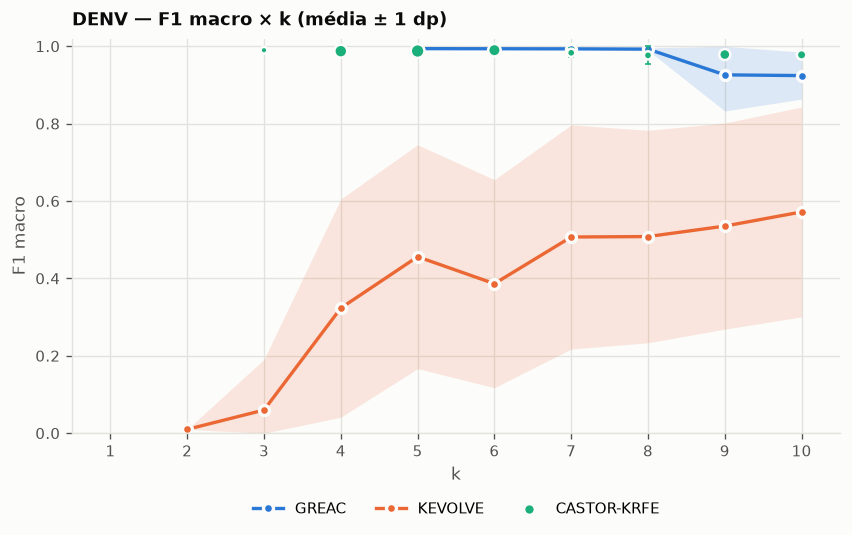

In [4]:
def draw(ax, value, log=False):
    """One series per method: line + band for the sweeps, points for CASTOR."""
    for m in METHODS:
        sub = per_k[per_k.method == m].sort_values("k")
        if sub.empty:
            continue
        mean, std = sub[f"{value}_mean"], sub[f"{value}_std"].fillna(0)
        if m == "CASTOR-KRFE":
            ax.errorbar(sub.k, mean, yerr=std, fmt="none", ecolor=COLOR[m], elinewidth=1, capsize=2)
            ax.scatter(sub.k, mean, s=12 + 4 * sub.n, color=COLOR[m], edgecolor=SURFACE,
                       linewidth=1.5, label=m, zorder=3)
            continue
        lo = (mean - std).clip(lower=mean.min() * 0.5 if log else 0)
        hi = mean + std if log else (mean + std).clip(upper=1)
        ax.fill_between(sub.k, lo, hi, color=COLOR[m], alpha=0.15, linewidth=0)
        ax.plot(sub.k, mean, marker="o", color=COLOR[m], label=m,
                markeredgecolor=SURFACE, markeredgewidth=2)
    ax.set_xticks(K_AXIS)
    ax.set_xlim(0.5, 10.5)
    ax.set_xlabel("k")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=3)


fig, ax = plt.subplots(figsize=(7.2, 4.6))
draw(ax, "f1")
ax.set_ylim(0, 1.02)
ax.set_ylabel("macro F1")
ax.set_title(f"{TITLE} — macro F1 × k (mean ± 1 SD)")
fig.tight_layout()
savefig(fig, "f1_vs_k.png")
plt.show()

## 2. Runtime × k

Same k axis, time on a log scale. GREAC: extraction + fit + classification of the combination shown in section 1.
KEVOLVE: the run with that k. CASTOR-KRFE: the whole run, which already includes the k search over
`k_min..k_max`, placed at the k it chose — so it is not comparable point by point with a fixed k, but with the
sum of the others' sweep (section 3).

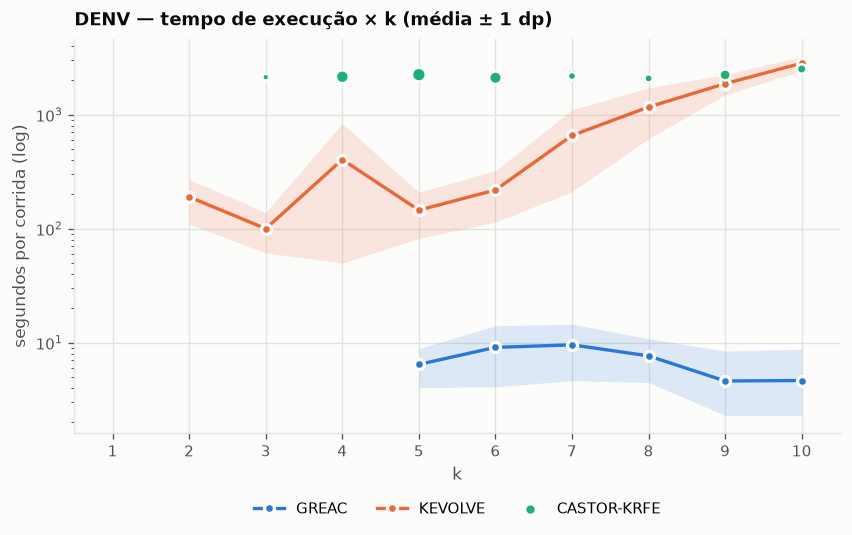

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
draw(ax, "seconds", log=True)
ax.set_yscale("log")
ax.set_ylabel("seconds per run (log)")
ax.set_title(f"{TITLE} — runtime × k (mean ± 1 SD)")
fig.tight_layout()
savefig(fig, "runtime_vs_k.png")
plt.show()

## 3. Best achievable F1 of each method, with its cost

- **GREAC and KEVOLVE**: the k with the highest mean F1 in their own sweep, with the time of one run at that k.
  `search_time_s` is the cost of *finding* that k, comparable to CASTOR-KRFE, which searches internally:
  for KEVOLVE, the sum of the mean time of every k; for GREAC, the sum of every window × threshold × k
  combination of the grid.
- **CASTOR-KRFE**: all runs together (choosing k is part of the method), with the most frequently chosen k.
  Taking the best subgroup per k would mean choosing k by looking at the test set.

The chart plots F1 against time: higher and further left is better.

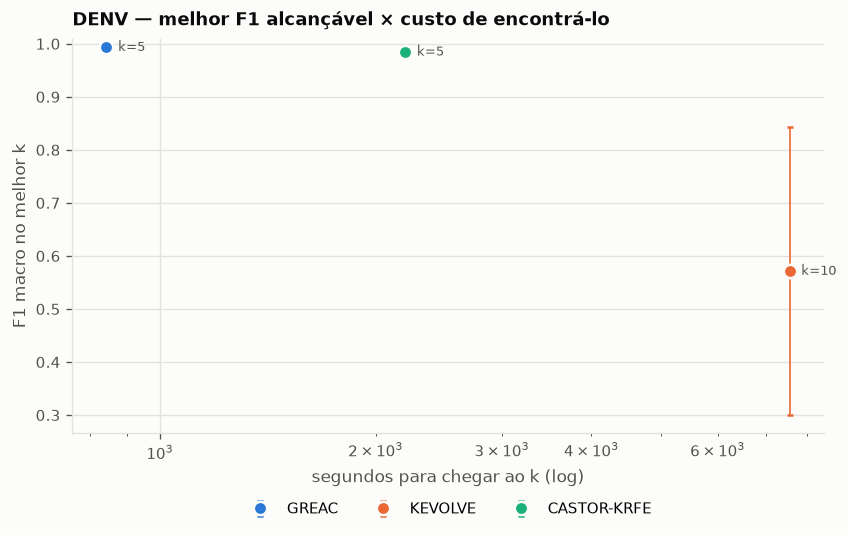

,method,k,n,f1_mean,f1_std,tempo_s,tempo_sweep_s
0,GREAC,5,100,0.994,0.002,6.433,842.365
1,KEVOLVE,10,76,0.572,0.271,2819.584,7560.098
2,CASTOR-KRFE,5,57,0.985,0.010,2199.403,2199.403


In [6]:
rows = []
for m in METHODS:
    sub = per_k[per_k.method == m]
    if sub.empty:
        continue
    if m == "CASTOR-KRFE":
        r = runs[runs.method == m]
        rows.append({"method": m, "k": int(r.k.mode().iloc[0]), "n": len(r),
                     "f1_mean": r.f1.mean(), "f1_std": r.f1.std(),
                     "time_s": r.seconds.mean(), "search_time_s": r.seconds.mean()})
        continue
    b = sub.loc[sub.f1_mean.idxmax()]
    rows.append({"method": m, "k": int(b.k), "n": int(b.n),
                 "f1_mean": b.f1_mean, "f1_std": b.f1_std,
                 "time_s": b.seconds_mean,
                 "search_time_s": GREAC_GRID_S if m == "GREAC" else sub.seconds_mean.sum()})
best = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for _, r in best.iterrows():
    ax.errorbar(r.search_time_s, r.f1_mean, yerr=0 if np.isnan(r.f1_std) else r.f1_std,
                fmt="o", color=COLOR[r.method], markersize=8, markeredgecolor=SURFACE,
                markeredgewidth=1.5, elinewidth=1, capsize=2, label=r.method)
    ax.annotate(f"k={r.k}", (r.search_time_s, r.f1_mean), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=8, color=INK_2)
ax.set_xscale("log")
ax.set_ylim(top=1.01)
ax.set_xlabel("seconds to reach that k (log)")
ax.set_ylabel("macro F1 at the best k")
ax.set_title(f"{TITLE} — best achievable F1 × cost of finding it")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=3)
fig.tight_layout()
savefig(fig, "best_f1_vs_cost.png")
plt.show()

best.to_csv(os.path.join(FIG_DIR, "best_per_method.csv"), index=False)
rounded(best)

## 4. Full table per k

F1 and time of every method per k. Written to `figs/comparison/<organism>/per_k.csv`.

In [7]:
per_k.to_csv(os.path.join(FIG_DIR, "per_k.csv"), index=False)
print("figures and tables in", FIG_DIR)
rounded(per_k.pivot_table(index="k", columns="method", values=["f1_mean", "seconds_mean"]))

figuras e tabelas em figs/comparison/denv


f1_mean                seconds_mean                 
method CASTOR-KRFE  GREAC KEVOLVE  CASTOR-KRFE  GREAC   KEVOLVE
k                                                              
2              NaN    NaN   0.010          NaN    NaN   189.585
3            0.990    NaN   0.060     2126.640    NaN    99.699
4            0.987    NaN   0.323     2143.814    NaN   403.081
5            0.988  0.994   0.456     2236.625  6.433   144.927
6            0.990  0.994   0.387     2101.378  9.072   217.792
7            0.983  0.994   0.507     2174.143  9.554   655.595
8            0.977  0.993   0.508     2075.467  7.640  1164.071
9            0.979  0.926   0.535     2224.680  4.602  1865.764
10           0.978  0.924   0.572     2507.878  4.644  2819.584